In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Slip (m)', ylabel='Depth (m)'>,
        <Axes: xlabel='Distance from fault (m)', ylabel='Horizontal displacement (m)'>],
       dtype=object))

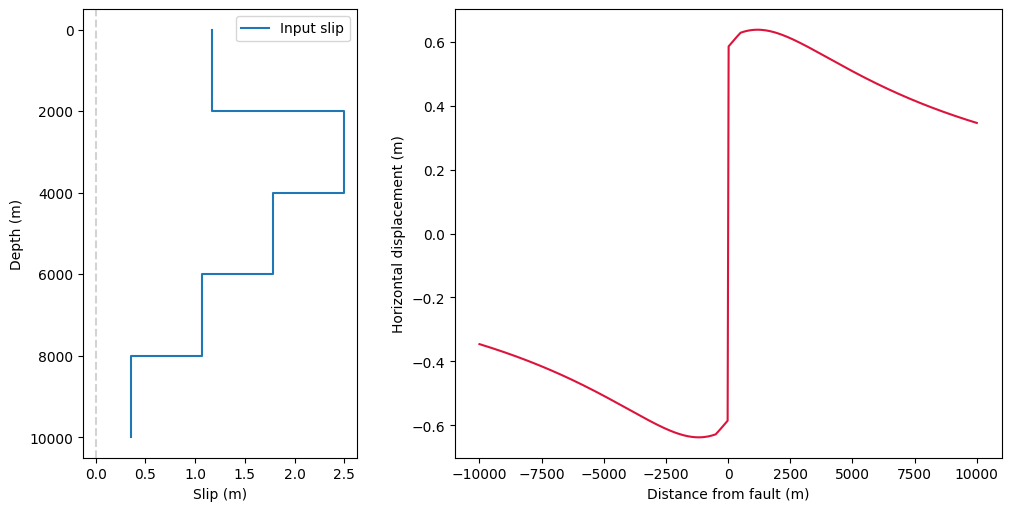

In [3]:
from codes import TwoDDzForwardModel
import numpy as np

model_dz = TwoDDzForwardModel()
model_dz = model_dz.build_uniform_patches(5, 10000.)
model_dz = model_dz.gen_triangular_slip_distribution()
xs = np.linspace(-10000, 10000, 500)
model_dz = model_dz.run(xs)

model_dz.plot()

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Slip (m)', ylabel='Depth (m)'>,
        <Axes: xlabel='Distance from fault (m)', ylabel='Horizontal displacement (m)'>],
       dtype=object))

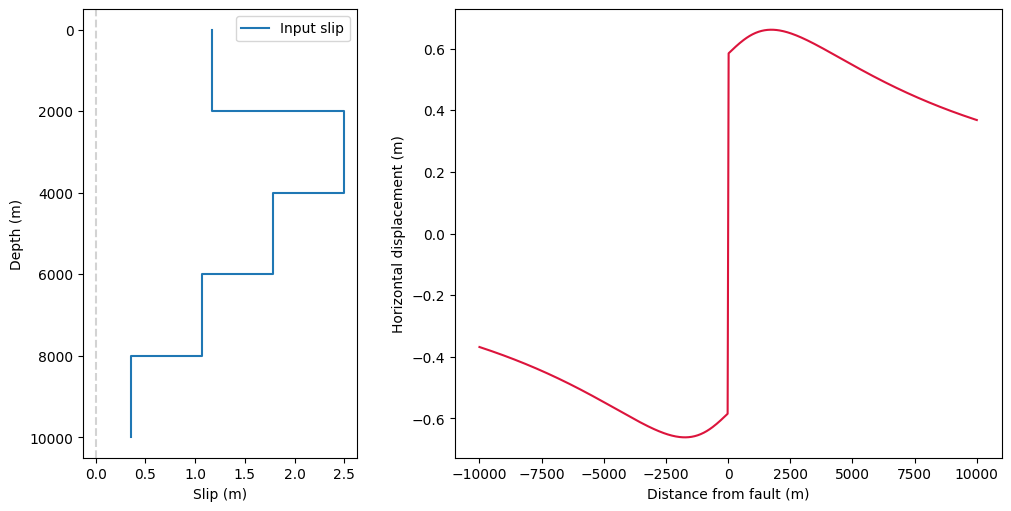

In [4]:
from codes import TwoDDzForwardModel
import numpy as np

model_nodz = TwoDDzForwardModel()
model_nodz.dz_half_width = 0.001
model_nodz = model_nodz.build_uniform_patches(5, 10000.)
model_nodz = model_nodz.gen_triangular_slip_distribution()
model_nodz = model_nodz.run(xs)

model_nodz.plot()

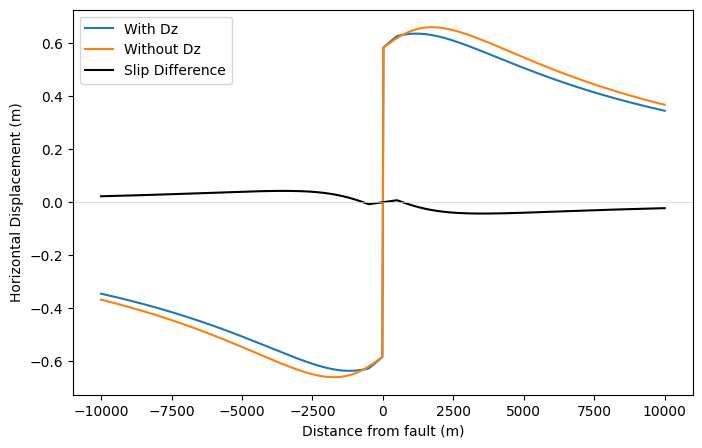

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(xs, model_dz.sol, label='With Dz')
ax.plot(xs, model_nodz.sol, label='Without Dz')
ax.plot(xs, (model_dz.sol - model_nodz.sol), label='Slip Difference', color="black")
ax.legend()
ax.set_xlabel('Distance from fault (m)')
ax.set_ylabel('Horizontal Displacement (m)')
ax.axhline(0, color='lightgray', lw=0.5)

plt.show()

In [14]:
from codes import TwoDHomogeneousForwardModel

n_patches = 50
fitting_model = TwoDHomogeneousForwardModel()
fitting_model = fitting_model.build_uniform_patches(n_patches, 10000.)

In [ ]:
import numpy as np
from codes import LeastSquaresInversion, UniformDist

# noise_lvl = 0.05
# data_covariance = noise_lvl**2 * np.eye(xs.size)
fitting_model.xs = xs

# priors = [UniformDist("dz_halfwidth", 0., 0.002)] + [UniformDist(f"slip{i}", 0., 2.) for i in range(n_patches)]
p0 = [[i]*10 for i in model_dz.slips]
p0 = np.array(p0).flatten()

inversion = LeastSquaresInversion(fitting_model, p0, model_dz.sol)
inversion = inversion.run()

Starting inversion...


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Slip (m)', ylabel='Depth (m)'>,
        <Axes: xlabel='Distance from fault (m)', ylabel='Horizontal displacement (m)'>],
       dtype=object))

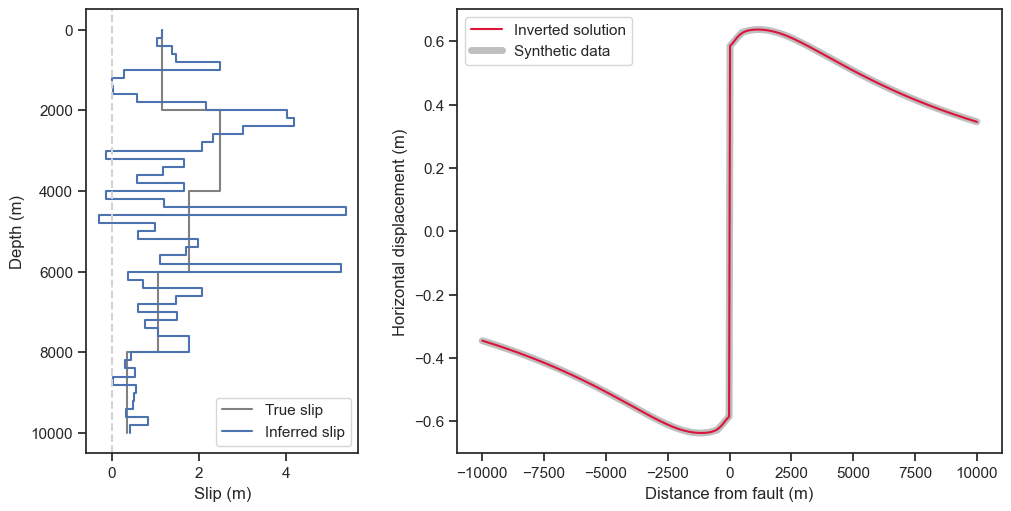

In [21]:
import seaborn as sns
sns.set_theme()
sns.set_style("ticks")
fitting_model.plot_inversion_result(inversion.result, model_dz.sol, title=None, true_slips=p0)

Starting inversion...


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Slip (m)', ylabel='Depth (m)'>,
        <Axes: xlabel='Distance from fault (m)', ylabel='Horizontal displacement (m)'>],
       dtype=object))

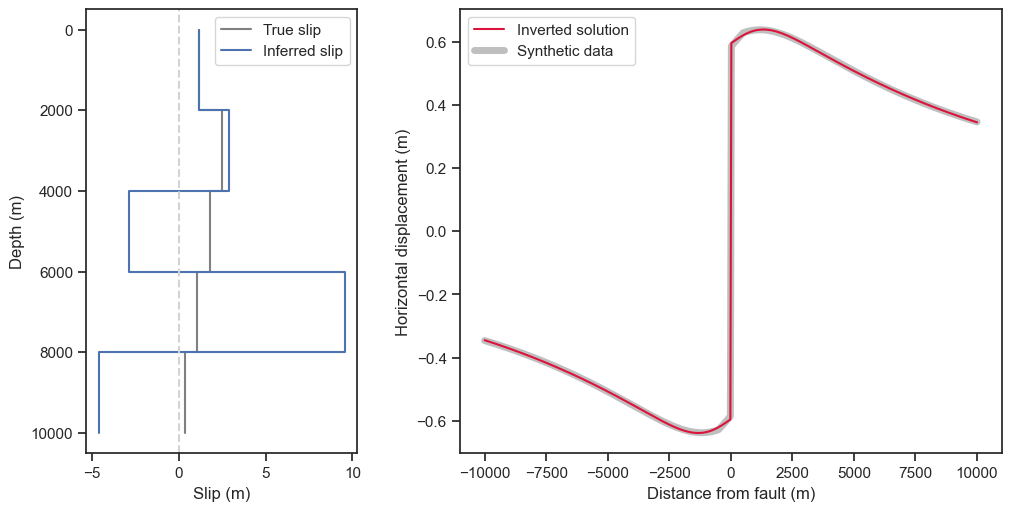

In [ ]:
from codes import TwoDHomogeneousForwardModel

model_dz = TwoDDzForwardModel()
model_dz = model_dz.build_uniform_patches(5, 10000.)
model_dz = model_dz.gen_triangular_slip_distribution()
xs = np.linspace(-10000, 10000, 500)
model_dz = model_dz.run(xs)

coarse_fitting_model = TwoDHomogeneousForwardModel()
coarse_fitting_model = coarse_fitting_model.build_uniform_patches(5, 10000.)
coarse_fitting_model.xs = xs

p0 = model_dz.slips

coarse_inversion = LeastSquaresInversion(coarse_fitting_model, p0, model_dz.sol)
coarse_inversion = coarse_inversion.run()

coarse_fitting_model.plot_inversion_result(coarse_inversion.result, model_dz.sol, title=None, true_slips=p0)

In [ ]:
from codes import TwoDDzForwardModel
import numpy as np

dzs = np.linspace(0., 1500., 30)

model_dz = TwoDDzForwardModel()
model_dz = model_dz.build_uniform_patches(5, 10000.)
model_dz = model_dz.gen_triangular_slip_distribution()
xs = np.linspace(-10000, 10000, 500)
model_dz = model_dz.run(xs)


model_dz.plot()